# 01 - FFT from scratch

Numerical core of the project. The goal is to show that we understand what happens under the hood:

1. we implement the **naive discrete Fourier transform (DFT)** in $O(n^2)$,
2. we implement the **fast Fourier transform (FFT)** via *Cooley-Tukey* in $O(n\log n)$,
3. we check correctness against `numpy` and compare **running times**.

All implementations live in `src/fft_scratch.py`; here we test and explain them.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
from matplotlib import pyplot as plt

import fft_scratch as F
import common

## 1. Discrete Fourier Transform (DFT)

Given a sequence $f_0, f_1, \dots, f_{N-1}$ of $N$ complex numbers, the discrete
Fourier transform maps it to a new sequence $\hat{f}_0, \dots, \hat{f}_{N-1}$:

$$\hat{f}_k = \sum_{n=0}^{N-1} f_n \, e^{-2\pi i k n / N}, \qquad k = 0, \dots, N-1.$$

This can be written in matrix form as $\hat{f} = W f$, where $W_{kn} = e^{-2\pi i k n / N}$.
Building and multiplying by $W$ costs $O(n^2)$ operations, which is what
`dft` does.

In [2]:
np.random.seed(0)
x = np.random.randn(8)

print('our dft:       ', np.round(F.dft(x)[:4], 3))
print('numpy.fft.fft: ', np.round(np.fft.fft(x)[:4], 3))

err = np.max(np.abs(F.dft(x) - np.fft.fft(x)))
print('max error:', err)
assert err < 1e-10
print('dft OK')

our dft:        [ 7.073+0.j    -0.821-2.694j  1.703+2.667j  0.614-2.637j]
numpy.fft.fft:  [ 7.073+0.j    -0.821-2.694j  1.703+2.667j  0.614-2.637j]
max error: 4.742874840267547e-15
dft OK


## 2. Fast Fourier Transform (Cooley-Tukey)

The naive DFT is too slow for real signals (a 3-minute audio clip has millions
of samples). In 1965 Cooley and Tukey published an algorithm that exploits
symmetries of $W$ and **recursively** splits the problem into two half-length
subproblems:

$$\hat{f}_k = \underbrace{\sum_{m} f_{2m}\, e^{-2\pi i k m /(N/2)}}_{\text{even indices}}
+ e^{-2\pi i k / N}\underbrace{\sum_{m} f_{2m+1}\, e^{-2\pi i k m /(N/2)}}_{\text{odd indices}}.$$

This brings the cost down from $O(n^2)$ to $O(n\log n)$. Our `fft` requires the
length to be a power of two; otherwise it zero-pads to the next power of two.

In [3]:
# Length that IS a power of two
x = np.random.randn(256)
err_pow2 = F.compare_with_numpy(x)
print('FFT error (N=256):', err_pow2)
assert err_pow2 < 1e-10

# Length that is NOT a power of two 
x2 = np.random.randn(300)
err_pad = F.compare_with_numpy(x2)
print('FFT error (N=300 -> 512):', err_pad)
assert err_pad < 1e-10
print('fft OK')

FFT error (N=256): 3.709141974507642e-14
FFT error (N=300 -> 512): 4.296434007659337e-14
fft OK


**Inverse FFT.** The transform must be invertible: `ifft(fft(x))` has to
return the original signal.

In [4]:
x = np.random.randn(128)
reconstructed = F.ifft(F.fft(x)).real

err_roundtrip = np.max(np.abs(reconstructed - x))
print('ifft(fft(x)) error:', err_roundtrip)
assert err_roundtrip < 1e-10
print('ifft round-trip OK')

ifft(fft(x)) error: 1.4432899320127035e-15
ifft round-trip OK


## 3. Complexity: $O(n^2)$ vs $O(n\log n)$

Now we measure running time of the naive DFT and our FFT for growing signal
lengths, and compare against the theoretical curves.

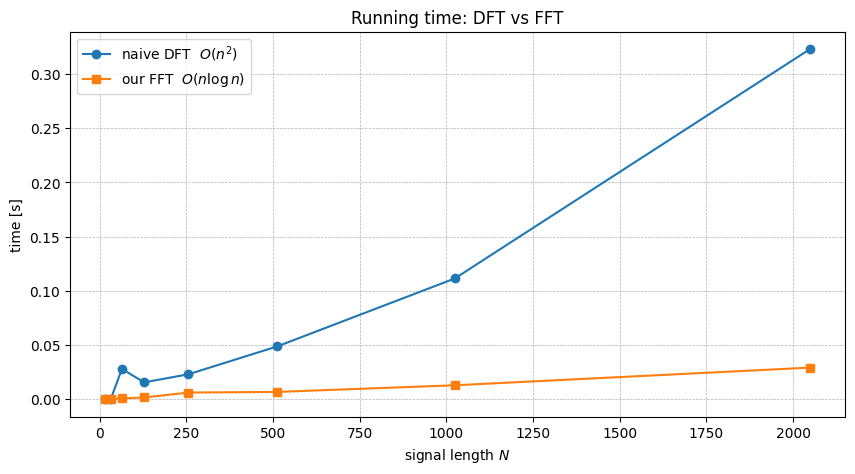

In [5]:
import time

lengths = [2**k for k in range(4, 12)]   # 16, 32, ..., 2048
time_dft, time_fft = [], []

for N in lengths:
    x = np.random.randn(N)

    t0 = time.perf_counter(); F.dft(x); time_dft.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); F.fft(x); time_fft.append(time.perf_counter() - t0)

plt.figure(figsize=(10, 5))
plt.plot(lengths, time_dft, 'o-', label='naive DFT  $O(n^2)$')
plt.plot(lengths, time_fft, 's-', label='our FFT  $O(n\\log n)$')
plt.xlabel('signal length $N$')
plt.ylabel('time [s]')
plt.title('Running time: DFT vs FFT')
plt.legend()
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

The gap grows quickly with $N$. On a log-log scale a power law $n^p$ shows up
as a straight line with slope $p$, so the two methods have visibly different
slopes.

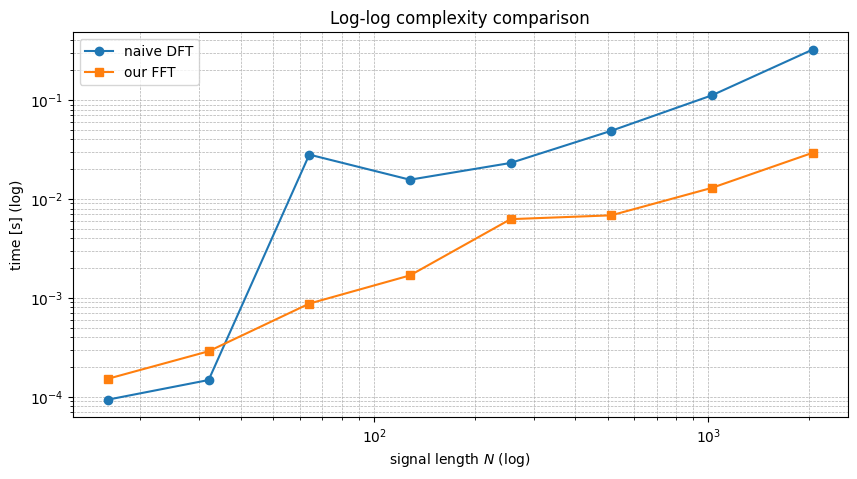

In [7]:
plt.figure(figsize=(10, 5))
plt.loglog(lengths, time_dft, 'o-', label='naive DFT')
plt.loglog(lengths, time_fft, 's-', label='our FFT')
plt.xlabel('signal length $N$ (log)')
plt.ylabel('time [s] (log)')
plt.title('Log-log complexity comparison')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## 4. Application: spectrum of a synthetic signal

To confirm our FFT actually extracts frequencies, we build a signal as the sum
of two sines (50 Hz and 120 Hz) plus a little noise, and look at its magnitude
spectrum. We reuse `generate_tone` / `plot_spectrum` from `common.py`.

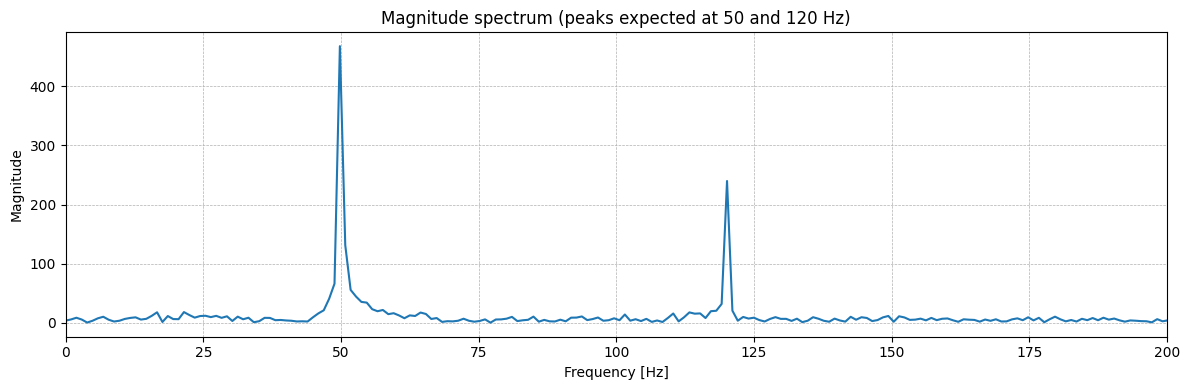

In [8]:
Fs = 1000
duration = 1.0
signal = (common.generate_tone(50, duration, Fs)
          + 0.5 * common.generate_tone(120, duration, Fs)
          + 0.2 * np.random.randn(int(Fs * duration)))

coeffs = F.fft(signal)
N = len(coeffs)
freq = F.freq_axis(N, Fs)

# Show only the positive frequencies
mask = freq >= 0
common.plot_spectrum(freq[mask], coeffs[mask],
                     title='Magnitude spectrum (peaks expected at 50 and 120 Hz)',
                     xlim=(0, 200))
plt.show()